# Aula 1 — Limpeza e Tratamento dos Dados

> **Data:** *(preencher)*  
> **Professor(a):** *(preencher)*

## 1. Contexto e motivação

### 1.1. De onde vêm os dados?

Você, membro do Insper Data e aluno do Ciclo Básico, naturalmente já passou noites em claro, suando frio e se questionando: “De onde vêm os dados? Onde vivem? O que comem? O que fazem?”. Embora o Globo Repórter ainda não esteja interessado em responder perguntas tão pertinentes (alô Sandra Annemberg, convida a gente), o Time Educacional do Insper Data não lhe deixará na mão.

Sem muito lero-lero, vamos direto ao assunto: **de onde vêm os dados?**

<div style="text-align: center;">
    <img src='img/globo_reporter.png' style="width: 500px;">
    <p style="font-style: italic;">Jhonatan Ramos, Diretor Educacional, em mais um dia de trabalho desvendando os mistérios dos dados</p>
</div>

Embora pareça, os dados não vêm na caixa do Banco Imobiliário (pelo menos não do tipo em que estamos interessados). São resultados de coleta ativa e intencional, que pode ocorrer de maneira física, por meio de formulários ou pesquisas *in loco*, como no caso do IBGE ou da prova do ENEM, ou por meio de sistemas automatizados de monitoramento de atividade, como no registro de transações realizadas em uma loja online.

A determinação de quais dados coletar, em qual volume e por qual meio, decorre de uma análise minuciosa que pode envolver diversas partes interessadas em uma empresa ou na sociedade.

Independentemente das dúvidas que guiarão o processo de montagem do sistema de coleta, uma certeza prevalece: no momento em que esse sistema entrar em contato com o mundo real (e com pessoas reais) ele falhará.

Do ponto de vista da Ciência de Dados, essa falha se manifesta como ruído: respostas em branco, erros de digitação, categorias inconsistentes, registros duplicados, valores impossíveis ou medições imprecisas. Seja por interferência sistemática, seja por mero acaso, o dado nunca nasce perfeito.

Trataremos em profundidade, ao longo do Ciclo Básico, dos aspectos relativos à coleta, utilização e às partes interessadas no contexto de bases de dados. Porém, daremos início a essa jornada a partir do que é mais mundano, e mais inevitável, no mundo da Ciência de Dados: a sujeira.

### 1.2. A sujeira

<div style="text-align: center;">
    <img src="img/sujeira.jpg" style="width: 500px;" />
    <p style="font-style: italic;">Aqui estão duas fotos. Uma é da sua base de dados e outra de um lixão nas Filipinas. Qual é qual?</p>
</div>

As origens da sujeira em bases de dados são diversas e podem ser motivadas tanto pelo design do sistema de coleta quanto por comportamentos fora do esperado — ou pela combinação de ambos.

Vamos supor que os membros do Insper Data desejem realizar uma pesquisa demográfica entre alunos do Insper. O presidente João Braga sugere as seguintes perguntas:

1. Qual a sua idade?
2. Qual o seu curso?
3. Qual seu estado de origem?
4. Qual sua cidade de origem?

Parece um questionário simples e imune a erros, certo? Errado.

Considere a primeira pergunta. Um respondente nascido em 11/03/2004 poderia responder “21”, “21 anos”, “vinte e um anos” ou até mesmo “vinte e um anos, onze meses e oito dias”, já que nenhuma especificação foi fornecida. Esse é um erro de design que inevitavelmente gerará inconsistência de formato na base de dados.

Percebendo o problema, o esperto Diretor de Pessoas, Sid, decide corrigir o questionário adicionando instruções claras:

1. Qual sua idade? (Em anos, apenas números. Exemplo: 21)
2. Qual o seu curso? (Assinale abaixo)

   * (a) Administração
   * (b) Ciência da Computação
   * (c) Direito
   * (d) Economia
   * (e) Engenharia da Computação
   * (f) Engenharia Mecânica
   * (g) Engenharia Mecatrônica
3. Qual seu estado de origem? (Apenas a sigla. Exemplo: “CE” para Ceará)
4. Qual sua cidade de origem?

Ainda assim, problemas permanecem. Alguns respondentes podem esquecer de responder uma pergunta, ignorar instruções ou cometer erros de digitação. Além disso, podemos deliberadamente criar perguntas de resposta opcional — como é comum em questões sobre sexualidade, por exemplo. Nesse caso, por design, estaríamos aceitando respostas vazias.

Isso ilustra um ponto central: a sujeira não é apenas um acidente. Ela é consequência natural de sistemas que interagem com o mundo real — e, em alguns casos, é uma escolha consciente de projeto.

Portanto, antes de qualquer análise, é essencial entender quais tipos de anomalias podem surgir nos dados e quais estratégias são adequadas para tratá-las.

## 2. Tipos comuns de "sujeira" nos dados

Vamos entrar no detalhe dos tipos de anomalias mais comuns em bases de dados. Para isso vamos usar a base `clientes.csv`, que já veio junto nesta pasta, dentro de `data_raw/`.

Toda aula funciona assim: `data_raw/` guarda a base **original**, que fica de referência e não deve ser mexida, e `data/` é a **cópia de trabalho** — é essa que os notebooks leem e é nela que você pode limpar, filtrar e alterar tudo. Se em algum momento você bagunçar a base, é só apagar o arquivo dentro de `data/` e rodar a célula de setup de novo: ela recria a cópia a partir do original.

Pronto. Agora vamos abrir a base de dados usando a biblioteca **Pandas** do Python. Assegure-se de ter o Python instalado, assim como as bibliotecas utilizadas abaixo. Você também pode seguir as instruções do arquivo `README.md` deste repositório para utilizar o ambiente virtual configurado por nós, que contém todas as bibliotecas.

In [1]:
import shutil
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

# A base vem junto nesta pasta, em data_raw/ — é o original, que fica de referência.
# data/ é a cópia de trabalho: é nela que vamos limpar e alterar a base.
# Bagunçou tudo? Apague data/clientes.csv e rode esta célula de novo.
Path('data').mkdir(exist_ok=True)
if not Path('data/clientes.csv').exists():
    shutil.copy('data_raw/clientes.csv', 'data/clientes.csv')

In [2]:
df = pd.read_csv('data/clientes.csv')
df.head(5)

,id_cliente,nome,email,idade,cidade,data_cadastro,telefone
0,679,GUSTAVO SLIVA,gustavo.sliva@gmail.com,32,rio de janeiro,2023-02-16 00:00:00,(70)92664-8803
1,880,Lucas dos Mendes,lucas.dos.mendes@empresa.com.br,41,sãopualo,2022-06-21 00:00:00,0000
2,901,pedro rocha,NaN,44,Salvador,2021-07-26 00:00:00,(83)91748-8658
3,244,Diego Pinto,diego.pinto256@yahoo.com.br,32,Niteroi,2022-05-11 00:00:00,XXXXX
4,329,HELENA MOURA,helena.moura@hotmail.com,79,sãopaulo,2023-04-25 00:00:00,(50)93669-3911


Lembre-se sempre de verificar as dimensões do seu dataset usando o comando `df.shape`. Saber quantas linhas tem o DataFrame será importante para estabelecer um parâmetro de comparação quando estivermos filtrando colunas ou removendo dados impróprios.

In [3]:
df.shape

(1248, 7)

### 2.1. Dados faltantes

Chamamos de dados faltantes (ou *missing values*) toda situação em que uma observação esperada não possui valor registrado. O sistema previa uma resposta, mas ela não está presente.

Isso pode acontecer por diferentes motivos:

- O respondente deixou a pergunta em branco.
- A pergunta era opcional.
- Houve erro de preenchimento ou falha no sistema.
- O dado simplesmente não foi coletado.

É importante notar: nem todo dado faltante é erro. Às vezes, ele é consequência do design do questionário; outras vezes, é falha operacional.

**Como identificar dados faltantes em uma base?**

Uma das formas mais simples é contar quantos valores ausentes existem em cada variável. Por exemplo, verificamos quantos emails estão faltando na base `clientes.csv` com o seguinte comando:

In [4]:
df['email'].isna().sum()

np.int64(111)

Esse comando faz três coisas:

- `isna()` identifica quais observações estão faltando (True para faltante, False caso contrário);
- `sum()` soma os True, contando quantos valores ausentes existem;
- o resultado nos diz quantos registros não possuem e-mail.

No nosso caso, encontramos **111 valores faltantes**.

### 2.2. Dados inconsistentes

Dizemos que há **dados inconsistentes** quando uma informação está registrada, mas não segue um padrão esperado.

Diferentemente dos dados faltantes, aqui o valor existe — porém aparece em formatos diferentes, grafias variadas ou categorias que deveriam representar a mesma coisa, mas foram registradas de formas distintas.

Isso pode acontecer por diversos motivos:

- Falta de padronização no sistema de coleta.
- Campo de resposta aberta quando deveria ser fechado.
- Erros de digitação.
- Uso de maiúsculas/minúsculas de forma inconsistente.
- Abreviações diferentes para o mesmo conceito.

Um exemplo clássico aparece na variável `cidade`.

In [5]:
df['cidade'].value_counts()

cidade
BH                    42
POA                   34
rio de janeiro        32
bh                    32
sp                    32
                      ..
 rio de janeiro        1
  Manaus               1
  Brasília             1
  RIO DE JANEIRO       1
fotraleza              1
Name: count, Length: 373, dtype: int64

O comando `value_counts` conta quantas vezes cada valor aparece em uma determinada coluna. Ele permite visualizar com facilidade categorias duplicadas sob grafias diferentes, além de ajudar a identificar padrões inesperados.

Ao aplicá-lo para a variável `cidade`, fica evidente o problema:

- `BH` e `bh` representam a mesma cidade.
- `rio de janeiro`, `Rio de Janeiro` e `RIO DE JANEIRO` também.
- Abreviações como `sp` convivem com nomes completos em outros registros.

Do ponto de vista semântico, são a mesma informação. Porém, do ponto de vista computacional, são categorias distintas.

Esse tipo de inconsistência pode:

- Inflar artificialmente o número de categorias.
- Distorcer gráficos e estatísticas.
- Prejudicar agrupamentos (groupby).
- Comprometer modelos que dependem de categorização correta.

### 2.3. Tipos incorretos

Nem toda inconsistência aparece como valor ausente ou erro de digitação. Em muitos casos, o problema está no tipo de dado atribuído à variável.

Uma coluna pode parecer correta na tabela, mas estar armazenada com um tipo inadequado. O erro não é visual, ele se manifesta apenas quando tentamos realizar operações como cálculos ou ordenações.

Para verificar o tipo de cada variável, podemos utilizar o comando `dtypes`:

In [6]:
df.dtypes

id_cliente       int64
nome               str
email              str
idade              str
cidade             str
data_cadastro      str
telefone           str
dtype: object

Esse comando:

- mostra o tipo de cada coluna do DataFrame;
- permite verificar se cada variável está representada da forma adequada para análise;
- ajuda a identificar possíveis inconsistências estruturais.

### 2.4. Duplicatas

**Duplicatas** são registros que aparecem mais de uma vez na base de dados, representando a mesma entidade ou a mesma observação.

A presença de duplicatas pode distorcer análises, inflar estatísticas e comprometer modelos preditivos. Se um mesmo cliente aparece duas vezes, por exemplo, ele passa a ter peso dobrado em qualquer cálculo.

Como a base possui um identificador (`id_cliente`), é natural verificar se ele se repete:

In [7]:
df['id_cliente'].duplicated().sum()

np.int64(48)

Esse comando:

- marca como True os valores que já apareceram anteriormente;
- soma esses casos;
- retorna o número de identificadores repetidos.

No nosso caso, encontramos **48 registros** cujo `id_cliente` já havia aparecido anteriormente na base.

### 2.5. Outliers

Chamamos de outliers os valores que se distanciam significativamente do padrão observado na base de dados.

Eles podem surgir por:

- erro de digitação;
- falha no sistema de coleta;
- interpretação equivocada da pergunta;
- ou simplesmente por representarem casos raros, mas legítimos.

Diferentemente de dados faltantes ou duplicatas, outliers não são necessariamente erros. O desafio está em distinguir valores improváveis de valores impossíveis.

No nosso caso, a variável `idade` é candidata natural para investigação.

No entanto, como vimos anteriormente, ela ainda está armazenada como `object`. Para realizar qualquer análise numérica, precisamos convertê-la temporariamente.

In [8]:
idade_temp = pd.to_numeric(df['idade'], errors='coerce')

Podemos então inspecionar seus extremos:

In [9]:
idade_temp.describe()

count    1215.000000
mean       65.292181
std       123.617113
min       -25.000000
25%        32.000000
50%        50.000000
75%        70.000000
max       999.000000
Name: idade, dtype: float64

É notável que a grande maioria dos valores estão dentro do esperado, porém há outliers, que nesse caso são valores impossíveis (idades negativas ou muito elevadas).

## 3. Técnicas de limpeza e tratamento

### 3.1. Tratando valores faltantes

Na etapa de diagnóstico, identificamos a presença de valores ausentes na variável `email`.

Diferentemente de variáveis numéricas como `idade`, não há um critério objetivo para imputar um endereço de e-mail. Trata-se de uma informação identificadora, específica de cada registro. Portanto, não é apropriado substituir valores faltantes por média, mediana ou qualquer regra estatística.

Nesse contexto, a decisão mais consistente é remover os registros que não possuem e-mail.

In [10]:
df = df.dropna(subset=['email'])

O parâmetro:

* `subset=['email']` indica que a remoção deve considerar apenas a variável `email`.

Após a remoção, podemos verificar:

In [11]:
df['email'].isna().sum()

np.int64(0)

O resultado esperado é **0**, indicando que não há mais valores faltantes nessa coluna.

**Observação**

A exclusão de registros é apenas uma das estratégias possíveis para lidar com dados faltantes.

Outras abordagens incluem:

* **Imputação estatística** (média, mediana, moda) — aplicável a variáveis numéricas;
* **Criação de categoria explícita** como "Não informado" — comum em variáveis categóricas;
* **Modelos preditivos de imputação** — em contextos mais avançados;
* **Manutenção dos valores ausentes**, quando a ausência é informativa.

A escolha do método depende:

* da natureza da variável;
* da proporção de valores ausentes;
* do objetivo da análise.

Neste caso específico, como o e-mail é uma informação essencial para identificação ou contato, optamos por manter apenas registros completos.


### 3.2. Padronização

Na etapa de diagnóstico, observamos que a variável `cidade` apresentava múltiplas grafias para a mesma informação:

* diferenças entre maiúsculas e minúsculas (`BH` vs `bh`);
* variações de capitalização (`rio de janeiro` vs `Rio de Janeiro`);
* possíveis abreviações e nomes completos convivendo na base.

Esse tipo de inconsistência não altera o significado da informação, mas fragmenta categorias que deveriam ser únicas.

**1. Normalização de texto**

O primeiro passo consiste em aplicar uma padronização estrutural:

In [12]:
df['cidade'] = (df['cidade']
        .str.strip()      # remove espaços extras
        .str.lower()      # converte para minúsculas
)

* `str.strip()` remove espaços no início e no fim;
* `str.lower()` elimina diferenças de capitalização.

Após essa etapa, `BH` e `bh` passam a ser tratados da mesma forma.

**2. Padronização semântica**

Ainda assim, abreviações e nomes completos continuam sendo categorias distintas. Para resolver isso, utilizamos um dicionário de mapeamento:

In [13]:
mapeamento_cidades = {
    'bh': 'belo horizonte',
    'sp': 'são paulo',
    'rj': 'rio de janeiro',
    'poa': 'porto alegre',
    'sjc': 'são josé dos campos',
}

df['cidade'] = df['cidade'].replace(mapeamento_cidades)

Esse passo garante que representações alternativas sejam convertidas para uma forma única.

**Verificando**

Podemos comparar antes e depois utilizando:

In [14]:
df['cidade'].value_counts()

cidade
são paulo              120
rio de janeiro         105
belo horizonte         105
porto alegre            76
são josé dos campos     44
                      ... 
aslvador                 1
soãpaulo                 1
porot alegre             1
rio d ejaneiro           1
rio ed janeiro           1
Name: count, Length: 103, dtype: int64

Espera-se observar:

* redução no número de categorias distintas;
* consolidação das frequências;
* eliminação de variações artificiais.

**Observação**

Padronizar não significa “embelezar” o dado, mas torná-lo consistente.

O objetivo é garantir que cada categoria represente exatamente um conceito — nem mais, nem menos.

Com isso, evitamos distorções em contagens, gráficos e modelos que dependem da correta agregação das informações.

### 3.3. Conversão de tipos

Após a etapa de diagnóstico, identificamos que as variáveis `idade` e `data_cadastro` estavam armazenadas como `str`, embora representem, respectivamente, valores numéricos e datas.

Antes de qualquer análise estatística ou temporal, é fundamental corrigir seus tipos.

**Conversão da variável `idade`**

Primeiro, convertemos a coluna para numérica:

In [15]:
df['idade'] = pd.to_numeric(df['idade'], errors='coerce')

- `pd.to_numeric()` tenta converter os valores para número;
- `errors='coerce'` transforma entradas inválidas em `NaN`, evitando que erros interrompam a execução;
- a atribuição direta substitui a coluna original.

Após a conversão, verificamos:

In [16]:
df['idade'].dtype

dtype('float64')

Agora a variável aparece como `float64`, que é um formato numérico plausível para análises de idade.

**Conversão da variável `data_cadastro`**

A variável `data_cadastro` representa datas, mas estava armazenada como texto. Para permitir operações temporais, realizamos a conversão:

In [17]:
df['data_cadastro'] = pd.to_datetime(df['data_cadastro'], errors='coerce')

- `pd.to_datetime()` converte a coluna para o tipo `datetime64`;
- `errors='coerce'` transforma datas inválidas em `NaT` (equivalente temporal de `NaN`).

Verificando o tipo:

In [18]:
df['data_cadastro'].dtype

dtype('<M8[us]')

**Por que essa etapa é importante?**

A conversão correta de tipos permite:

- calcular média, mediana e desvio padrão da idade;
- aplicar filtros numéricos adequados;
- extrair ano, mês ou dia da data de cadastro;
- calcular tempo desde o cadastro;
- ordenar cronologicamente os registros.

Sem essa padronização estrutural, qualquer análise subsequente estaria sujeita a erros silenciosos ou interpretações equivocadas.

A partir deste ponto, as variáveis passam a estar adequadamente tipadas, permitindo avançar para o tratamento de inconsistências e valores extremos de forma segura.

### 3.4. Remoção de duplicatas

Na etapa de diagnóstico, identificamos a existência de **48 registros duplicados** com base na variável `id_cliente`.

Como `id_cliente` deve representar um identificador único, sua repetição indica redundância na base. Nesses casos, a abordagem mais direta consiste em manter apenas uma ocorrência de cada identificador.

**Verificação inicial**

Antes da remoção, podemos confirmar a quantidade de duplicatas:

In [19]:
df['id_cliente'].duplicated().sum()

np.int64(45)

**Remoção das duplicatas**

Para manter apenas a primeira ocorrência de cada `id_cliente`, utilizamos:

In [20]:
df = df.drop_duplicates(subset='id_cliente', keep='first')

Parâmetros utilizados:

* `subset='id_cliente'` → define a coluna usada como critério de duplicação;
* `keep='first'` → mantém a primeira ocorrência e remove as demais.

Confirmamos a remoção:

In [21]:
df['id_cliente'].duplicated().sum()

np.int64(0)

**Observação**

A decisão de manter a primeira ocorrência pressupõe que:

* não há diferença relevante entre os registros duplicados;
* ou que a primeira entrada é considerada a versão válida.

Em contextos reais, pode ser necessário investigar os registros repetidos antes da exclusão, especialmente se houver divergências entre eles.

Neste caso, como `id_cliente` deve ser único por definição, a remoção das duplicatas garante a integridade estrutural da base.

### 3.5. Remoção de outliers

Após a conversão para tipo numérico, é possível analisar a distribuição da variável `idade` e identificar valores extremos.

Uma inspeção inicial pode ser feita com:

In [22]:
df['idade'].describe()

count    1061.000000
mean       62.044298
std       111.451008
min       -25.000000
25%        30.000000
50%        50.000000
75%        70.000000
max       999.000000
Name: idade, dtype: float64

Ou visualmente:

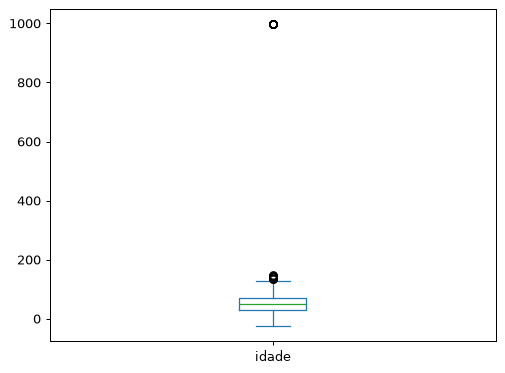

<Axes: >

In [23]:
df['idade'].plot.box()

A partir dessa análise, observamos a presença de valores incompatíveis com o contexto da base — por exemplo, idades muito elevadas ou negativas.

#### Definição de critério

Antes de remover ou ajustar valores, é necessário definir um critério objetivo.

Duas abordagens comuns são:

**1. Critério de domínio (regra de negócio)**

Se sabemos que a base se refere a alunos de graduação, por exemplo, podemos definir limites plausíveis:

* idade mínima: 15 anos
* idade máxima: 100 anos

In [24]:
df = df.loc[(df['idade'] >= 15) & (df['idade'] <= 100), :]

**2. Critério estatístico (IQR)**

Uma alternativa é utilizar o intervalo interquartil:

In [25]:
Q1 = df['idade'].quantile(0.25)
Q3 = df['idade'].quantile(0.75)
IQR = Q3 - Q1

limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR

df = df.loc[(df['idade'] >= limite_inferior) & (df['idade'] <= limite_superior), :]

## Observação importante

Outliers não são automaticamente erros.

* Um valor extremo pode ser fruto de erro de digitação (ex: 222 anos).
* Pode ser erro de unidade.
* Ou pode ser um caso raro, mas legítimo.

Por isso, o tratamento deve sempre ser contextualizado.

Neste caso, considerando a natureza da base, valores extremamente elevados ou negativos não são plausíveis — portanto, optamos por tratá-los como inválidos.


## 4. Combinando tabelas

### 4.1. Por que combinar tabelas?

Até aqui trabalhamos com uma única base: `clientes.csv`. Na prática, isso quase nunca acontece.

Os dados de uma empresa costumam estar **espalhados em vários lugares**:

* o cadastro dos clientes vive no sistema de CRM;
* as compras ficam no sistema de vendas;
* as respostas da pesquisa de satisfação vieram de um formulário à parte;
* e a base do mês passado chegou num arquivo separado da base deste mês.

Nenhuma dessas tabelas isolada responde à pergunta que interessa — *"quem são os clientes que mais
compram?"*. Para responder, é preciso **juntar as tabelas**.

Existem duas operações diferentes para isso, e confundi-las é um erro clássico:

| Situação | O que você quer | Ferramenta |
|---|---|---|
| Duas tabelas com **as mesmas colunas** (base de janeiro + base de fevereiro) | acrescentar **linhas** | `pd.concat()` |
| Duas tabelas com **informações diferentes** sobre as mesmas entidades (cadastro + compras) | acrescentar **colunas**, cruzando por uma chave | `pd.merge()` |

Em uma frase: **`concat` empilha, `merge` cruza.**

### 4.2. `pd.concat()` — empilhando registros

Use quando as tabelas descrevem **o mesmo tipo de coisa** e têm a mesma estrutura de colunas.

Vamos simular a situação: o cadastro de clientes foi exportado em dois arquivos, um por escritório.

In [26]:
clientes_sp = pd.DataFrame({
    'id_cliente': [1, 2],
    'nome':       ['Ana', 'Bruno'],
    'cidade':     ['são paulo', 'são paulo'],
})

clientes_rj = pd.DataFrame({
    'id_cliente': [3, 4],
    'nome':       ['Carla', 'Diego'],
    'cidade':     ['rio de janeiro', 'rio de janeiro'],
})

clientes_sp

,id_cliente,nome,cidade
0,1,Ana,são paulo
1,2,Bruno,são paulo


In [27]:
cadastro = pd.concat([clientes_sp, clientes_rj], ignore_index=True)
cadastro

,id_cliente,nome,cidade
0,1,Ana,são paulo
1,2,Bruno,são paulo
2,3,Carla,rio de janeiro
3,4,Diego,rio de janeiro


Os parâmetros utilizados:

* a **lista** `[clientes_sp, clientes_rj]` define a ordem em que as tabelas são empilhadas;
* `ignore_index=True` recria o índice de 0 a n-1 — sem ele, os índices originais se repetiriam
  (0, 1, 0, 1), o que costuma causar confusão mais adiante.

O resultado tem **4 linhas e 3 colunas**: o mesmo conjunto de colunas, com mais registros.

**Atenção:** se as colunas não forem exatamente iguais nas duas tabelas, o `concat` não dá erro —
ele cria a coluna que faltava e preenche com `NaN`. Ou seja, um simples erro de digitação no nome
de uma coluna (`cidade` vs `Cidade`) gera silenciosamente uma base cheia de valores faltantes.

### 4.3. `pd.merge()` — cruzando por uma chave

Agora o caso mais comum: duas tabelas que guardam **informações diferentes** e se conectam por
uma coluna em comum — a **chave**. No nosso exemplo, a chave é o `id_cliente`.

Vamos supor que o sistema de vendas nos entregou a tabela de compras:

In [28]:
compras = pd.DataFrame({
    'id_cliente': [1, 1, 2, 5],
    'produto':    ['Notebook', 'Mouse', 'Cadeira', 'Monitor'],
    'valor':      [4500.00, 120.00, 890.00, 1200.00],
})

compras

,id_cliente,produto,valor
0,1,Notebook,4500.0
1,1,Mouse,120.0
2,2,Cadeira,890.0
3,5,Monitor,1200.0


Repare que as duas tabelas **não se sobrepõem perfeitamente** — e é justamente aí que mora a
decisão importante:

* **Ana (1)** aparece duas vezes em compras (comprou dois produtos);
* **Carla (3)** e **Diego (4)** estão no cadastro, mas nunca compraram nada;
* o **cliente 5** comprou um monitor, mas **não existe no cadastro** (provavelmente um problema de
  qualidade de dados — do tipo que aprendemos a diagnosticar na seção 2).

O que fazer com esses casos? Depende do tipo de junção.

### 4.4. Os tipos de junção

O parâmetro `how` do `pd.merge()` define **quais linhas sobrevivem** à junção:

| `how` | Mantém | Quando usar |
|---|---|---|
| `'inner'` | só as chaves presentes **nas duas** tabelas | quando você só quer analisar quem tem informação completa |
| `'left'` | **todas** as da tabela da esquerda | quando a tabela da esquerda é a sua base principal e o resto é complemento |
| `'right'` | **todas** as da tabela da direita | mesma lógica do `left`, invertida (na prática, é mais comum inverter a ordem e usar `left`) |
| `'outer'` | **todas** as chaves das duas | quando você quer enxergar o que falta de cada lado |

O padrão do pandas é `'inner'`. Vamos ver os três principais na prática.

In [29]:
# INNER — só quem existe nas duas tabelas
pd.merge(cadastro, compras, on='id_cliente', how='inner')

,id_cliente,nome,cidade,produto,valor
0,1,Ana,são paulo,Notebook,4500.0
1,1,Ana,são paulo,Mouse,120.0
2,2,Bruno,são paulo,Cadeira,890.0


Resultado: **3 linhas**. Carla, Diego e o cliente 5 desapareceram.

O `inner` é o mais "seguro" no sentido de não gerar valores faltantes — mas é o mais perigoso no
sentido de **descartar dados sem avisar**. Você pediu uma análise de 4 clientes e recebeu 2.

In [30]:
# LEFT — todo o cadastro, com as compras quando existirem
pd.merge(cadastro, compras, on='id_cliente', how='left')

,id_cliente,nome,cidade,produto,valor
0,1,Ana,são paulo,Notebook,4500.0
1,1,Ana,são paulo,Mouse,120.0
2,2,Bruno,são paulo,Cadeira,890.0
3,3,Carla,rio de janeiro,NaN,NaN
4,4,Diego,rio de janeiro,NaN,NaN


Resultado: **5 linhas**. Carla e Diego aparecem com `NaN` em `produto` e `valor`.

Esse é geralmente o comportamento desejado quando existe uma **tabela principal**: você quer
manter todos os clientes, mesmo os que não compraram. Os `NaN` que surgem aqui não são sujeira —
eles têm significado: *"esse cliente não comprou nada"*.

In [31]:
# OUTER — tudo de todo mundo, para enxergar os furos
pd.merge(cadastro, compras, on='id_cliente', how='outer')

,id_cliente,nome,cidade,produto,valor
0,1,Ana,são paulo,Notebook,4500.0
1,1,Ana,são paulo,Mouse,120.0
2,2,Bruno,são paulo,Cadeira,890.0
3,3,Carla,rio de janeiro,NaN,NaN
4,4,Diego,rio de janeiro,NaN,NaN
5,5,NaN,NaN,Monitor,1200.0


Resultado: **6 linhas**. Além de Carla e Diego, aparece agora o cliente 5, com `NaN` no nome e
na cidade.

O `outer` raramente é o resultado final de uma análise, mas é excelente como **ferramenta de
diagnóstico**: ele escancara as chaves que existem de um lado e não do outro.

### 4.5. Cuidados ao juntar tabelas

Combinar tabelas é onde muita base "boa" vira base ruim. Três armadilhas que valem por si só:

**1. A chave precisa estar padronizada**

Um `merge` compara os valores da chave **exatamente**. `"Ana"` e `"ana "` são clientes diferentes
para o pandas. Se a sua chave é um texto (nome, e-mail, cidade), aplique antes a padronização que
vimos na seção 3.2 — caso contrário, o cruzamento simplesmente não encontra os pares.

**2. O número de linhas pode aumentar**

Repare no que aconteceu com a Ana: ela era **uma** linha no cadastro e virou **duas** no resultado,
porque tinha duas compras. Isso é o comportamento correto, mas se você não estava esperando, sua
"base de clientes" de repente conta gente em dobro — e toda média calculada em cima dela fica errada.

**3. Sempre confira o `shape` antes e depois**

É o hábito mais barato de adquirir e o que mais evita dor de cabeça:

In [32]:
resultado = pd.merge(cadastro, compras, on='id_cliente', how='left')

print('cadastro: ', cadastro.shape)
print('compras:  ', compras.shape)
print('resultado:', resultado.shape)
print()
print('Clientes sem nenhuma compra:', resultado['produto'].isna().sum())

cadastro:  (4, 3)
compras:   (4, 3)
resultado: (5, 5)

Clientes sem nenhuma compra: 2


Se o número de linhas do resultado for **maior** do que o da sua tabela principal, pare e entenda
por quê antes de seguir. Quase sempre a explicação é uma destas duas:

* a chave se repete na outra tabela (como no caso da Ana — o que é esperado); ou
* existem duplicatas na chave que você deveria ter tratado antes (revisite a seção 3.4).

**Observação**

Juntar tabelas não é uma operação puramente técnica. Escolher entre `inner` e `left` é escolher
**quem entra na sua análise** — e essa decisão muda o resultado final. Antes de digitar o `how`,
responda: *"clientes que nunca compraram fazem parte da pergunta que estou respondendo?"*

## 5. Mão na massa

Continue fazendo a limpeza da base `clientes.csv`. Começamos bem, mas ainda há muito a ser corrigido. Você pode pedir ajuda dos professores para identificar outras falhas e tratá-las.

**Diagnóstico:** antes de sair corrigindo, vale olhar o que sobrou de sujeira depois
das etapas anteriores.

In [33]:
print('Linhas restantes:', df.shape[0])
print()
print('Nulos por coluna:')
print(df.isna().sum().to_string())
print()
print('Nomes fora do padrão (espaço sobrando ou capitalização errada):',
      (df['nome'] != df['nome'].str.strip().str.title()).sum())
print('Telefones preenchidos com XXXXX ou 0000:',
      df['telefone'].isin(['XXXXX', '0000']).sum())
print('Categorias distintas na coluna cidade:', df['cidade'].nunique())

Linhas restantes: 983

Nulos por coluna:
id_cliente        0
nome              0
email             0
idade             0
cidade           32
data_cadastro     0
telefone         64

Nomes fora do padrão (espaço sobrando ou capitalização errada): 676
Telefones preenchidos com XXXXX ou 0000: 137
Categorias distintas na coluna cidade: 97


### 1. `nome`: espaços e capitalização

O mesmo problema da coluna `cidade`, resolvido do mesmo jeito. `str.title()` deixa a primeira
letra de cada palavra em maiúscula.

In [34]:
df['nome'] = df['nome'].str.strip().str.title()

print(df['nome'].head(8).to_string())

0       Gustavo Sliva
1    Lucas Dos Mendes
3         Diego Pinto
4        Helena Moura
5           M. Araujo
6        Caimla Moura
8      Larissa Campos
9        Rafael Moura


### 2. `email`: endereços que existem, mas não são válidos

Aqui a sujeira é diferente das anteriores: o campo está preenchido, mas com um valor que não é
um e-mail. Usamos uma **expressão regular** para descrever o formato esperado (`algo@algo.algo`)
e separar o que passa do que não passa.

In [35]:
padrao_email = r'^[\w\.\-]+@[\w\-]+\.[\w\.\-]+$'
email_valido = df['email'].str.match(padrao_email)

print('E-mails fora do padrão:', (~email_valido).sum())
print()
print('Alguns exemplos do que foi reprovado:')
print(df.loc[~email_valido, 'email'].head(8).to_string(index=False))

E-mails fora do padrão: 116

Alguns exemplos do que foi reprovado:
            larissa.camposgmail.com
                    mariana.souza@ 
                     diego.campos@ 
           igor.nunes@user#mail.com
   fernanda.dos.pinto@user#mail.com
gustavot.eixeira@mail(at)domain.com
                 gustavo.silva@None
  carlos.ribeiro@mail(at)domain.com


In [36]:
# Não há como adivinhar o endereço certo, então o inválido vira nulo.
df.loc[~email_valido, 'email'] = pd.NA

# A seção 3.1 já tinha decidido que cliente sem e-mail não serve para esta base.
# Sendo coerentes com aquela decisão, removemos também esses.
antes = df.shape[0]
df = df.dropna(subset=['email'])
print(f'Linhas removidas por e-mail inválido: {antes - df.shape[0]}')
print(f'Linhas restantes: {df.shape[0]}')

Linhas removidas por e-mail inválido: 116
Linhas restantes: 867


### 3. `telefone`: valores de preenchimento

`XXXXX` e `0000` não são telefones, são o que o sistema gravou quando não tinha o dado. Deixá-los
como texto é pior do que assumir o nulo: qualquer contagem de "clientes com telefone" sairia
inflada.

In [37]:
df['telefone'] = df['telefone'].replace(['XXXXX', '0000'], pd.NA)

# Do que sobrou, guardamos só os dígitos: (11)91234-5678 vira 11912345678
df['telefone'] = df['telefone'].str.replace(r'\D', '', regex=True)

# E o que tem menos de 10 dígitos não é um telefone brasileiro válido
curto = (df['telefone'].str.len() < 10).fillna(False)
df.loc[curto, 'telefone'] = pd.NA

print('Telefones válidos:', df['telefone'].notna().sum(), 'de', df.shape[0])
print()
print(df['telefone'].head(8).to_string())

Telefones válidos: 691 de 867

0     70926648803
1             NaN
3             NaN
4     50936693911
5     96920726543
6     87957641606
9     74931105162
11    36963138251


### 4. `cidade`, de novo: erros de digitação

A padronização da seção 3.2 resolveu maiúsculas e abreviações, mas sobrou uma família de
problemas que um dicionário fixo não alcança: **erros de digitação**, do tipo `sãopualo`,
`nitreoi`, `belo horizotne`. São dezenas de variações, cada uma aparecendo uma ou duas vezes.

A estratégia tem três passos:

1. **normalizar** (minúsculas, sem acento, sem espaço), o que já junta `São Paulo`, `sao paulo` e
   `SÃOPAULO`;
2. traduzir as **abreviações** conhecidas;
3. para o que sobrar, procurar o nome oficial **mais parecido** com `difflib.get_close_matches`,
   que compara texto por semelhança. `sãopualo` está a uma troca de letras de `saopaulo`.

In [38]:
import unicodedata
from difflib import get_close_matches

def normaliza(texto):
    """'São  Paulo' e 'sao paulo' viram os dois 'saopaulo'."""
    if pd.isna(texto):
        return texto
    texto = str(texto).strip().lower()
    texto = unicodedata.normalize('NFKD', texto).encode('ascii', 'ignore').decode()
    return texto.replace(' ', '')

# Nomes que aceitamos na base, na forma normalizada -> forma final
oficiais = {
    'saopaulo': 'são paulo',           'riodejaneiro': 'rio de janeiro',
    'belohorizonte': 'belo horizonte', 'portoalegre': 'porto alegre',
    'saojosedoscampos': 'são josé dos campos',
    'recife': 'recife',                'fortaleza': 'fortaleza',
    'niteroi': 'niterói',              'manaus': 'manaus',
    'brasilia': 'brasília',            'curitiba': 'curitiba',
    'campinas': 'campinas',            'goiania': 'goiânia',
    'vilavelha': 'vila velha',         'salvador': 'salvador',
}

abreviacoes = {'sp': 'saopaulo', 'bh': 'belohorizonte', 'rj': 'riodejaneiro',
               'rio': 'riodejaneiro', 'poa': 'portoalegre',
               'sjc': 'saojosedoscampos', 'ctba': 'curitiba'}

def padroniza_cidade(valor):
    chave = normaliza(valor)
    if pd.isna(chave) or chave in ('', 'desconhecido'):
        return pd.NA
    chave = abreviacoes.get(chave, chave)
    if chave in oficiais:
        return oficiais[chave]
    # erro de digitação: procura o nome oficial mais parecido
    parecidos = get_close_matches(chave, list(oficiais), n=1, cutoff=0.8)
    return oficiais[parecidos[0]] if parecidos else pd.NA

antes = df['cidade'].nunique()
df['cidade'] = df['cidade'].apply(padroniza_cidade)

print(f'Categorias distintas em cidade: {antes} -> {df["cidade"].nunique()}')
print()
print(df['cidade'].value_counts(dropna=False).to_string())

Categorias distintas em cidade: 92 -> 15

cidade
são paulo              152
rio de janeiro         106
belo horizonte          81
NaN                     74
são josé dos campos     65
porto alegre            62
niterói                 53
curitiba                51
recife                  37
brasília                31
manaus                  30
fortaleza               28
goiânia                 28
campinas                25
vila velha              23
salvador                21


> ⚠️ **Cuidado com o `get_close_matches`.** Ele resolve muita coisa de uma vez, mas é um chute
> calculado: se duas cidades tivessem nomes parecidos de verdade, ele poderia trocar uma pela
> outra. Em base de produção, o certo é conferir a lista de correções antes de aplicar, ou
> comparar com uma tabela oficial de municípios (a do IBGE, por exemplo).

### 5. Conferência final

Toda limpeza termina com a mesma pergunta: sobrou algum problema, e quanto da base foi perdido
no caminho?

In [39]:
print('Formato final:', df.shape, ' (a base original tinha 1.248 linhas)')
print()
print('Nulos restantes:')
print(df.isna().sum().to_string())
print()
print('Tipos das colunas:')
print(df.dtypes.to_string())
print()
print(df.head().to_string())

Formato final: (867, 7)  (a base original tinha 1.248 linhas)

Nulos restantes:
id_cliente         0
nome               0
email              0
idade              0
cidade            74
data_cadastro      0
telefone         176

Tipos das colunas:
id_cliente                int64
nome                        str
email                       str
idade                   float64
cidade                      str
data_cadastro    datetime64[us]
telefone                    str

   id_cliente              nome                            email  idade          cidade data_cadastro     telefone
0         679     Gustavo Sliva          gustavo.sliva@gmail.com   32.0  rio de janeiro    2023-02-16  70926648803
1         880  Lucas Dos Mendes  lucas.dos.mendes@empresa.com.br   41.0       são paulo    2022-06-21          NaN
3         244       Diego Pinto      diego.pinto256@yahoo.com.br   32.0         niterói    2022-05-11          NaN
4         329      Helena Moura         helena.moura@hotmail.com   7

In [40]:
# A base tratada é salva em data/, e data_raw/ continua intocado.
df.to_csv('data/clientes_limpo.csv', index=False)
print('Base limpa salva em data/clientes_limpo.csv')

Base limpa salva em data/clientes_limpo.csv


> **✅ Resumo das decisões desta limpeza**
>
> | Coluna | Problema | Decisão | Por quê |
> |---|---|---|---|
> | `email` | 111 nulos + 116 inválidos | remover as linhas | é identificador, não dá para imputar, e a base exige contato |
> | `nome` | espaços e caixa irregular | `strip` + `title` | mesma pessoa não pode virar duas categorias |
> | `cidade` | abreviação, acento, digitação | normalizar, mapear e aproximar | 90+ categorias artificiais viram 15 reais |
> | `telefone` | `XXXXX` e `0000` | virar nulo e guardar só dígitos | nulo honesto vale mais que dado falso |
> | `idade` | texto, negativos e 200+ anos | `to_numeric` + faixa 15 a 100 + IQR | valor impossível é erro, não outlier legítimo |
> | `data_cadastro` | texto | `to_datetime` | sem isso não dá para ordenar nem filtrar por período |
> | `id_cliente` | 48 repetidos | `drop_duplicates` | identificador duplicado dobra o peso do cliente |
>
> **O que mais chama atenção:** a base começou com 1.248 linhas e terminou com menos de 900. Perder
> quase 30% não é fracasso da limpeza, é o retrato da qualidade do que foi coletado. E cada
> remoção aqui foi uma **escolha**, não uma regra automática: em outro contexto, um cliente sem
> e-mail poderia continuar valendo para uma análise de idade e cidade.
>
> Por isso, a regra de ouro: **anote toda decisão de limpeza**. O número final da sua análise
> depende delas tanto quanto do código.